In [99]:
from gerrychain import Graph
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain, proposals, updaters, constraints, accept, Election)
from gerrychain.proposals import recom, propose_random_flip
from gerrychain.tree import recursive_tree_part, bipartition_tree, find_balanced_edge_cuts_memoization
from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias
from gerrychain.updaters import cut_edges

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

from functools import partial
import numpy as np
import csv
import pandas as pd
import maup

In [2]:
CON_NC = gpd.read_file("./NC/NC_Processed/nc_cong_adopted_2025/NCGA_CCM-2 - Shapefile/CCM-2.shp")

In [105]:
CON_NC22 = gpd.read_file("./NC/NC_Processed/nc_cong_adopted_2022/NC_SMmap2_Statewide.shp")

In [3]:
CON_SC = gpd.read_file("./SC/SC_Processed/sc_cong_adopted_2022/S865_Congress.shp")

In [4]:
CON_GA = gpd.read_file("./GA/GA_Processed/ga_cong_adopted_2023/Congress-2023 shape.shp")

In [93]:
CON_FL = gpd.read_file("./FL/FL_Processed/fl_cong_adopted_2026/EOGPCRP2026/EOGPCRP2026.shp")

In [101]:
CON_FL22 = gpd.read_file("./FL/FL_Processed/fl_cong_adopted_2022/P000C0109.shx")

In [6]:
df_nc = gpd.read_file("./NC/NC_Processed/output/NC_Processed_Precincts.shp")

In [7]:
df_ga = gpd.read_file("./GA/GA_Processed/output/GA_Processed_Precincts.shp")

In [8]:
df_sc = gpd.read_file("./SC/SC_Processed/output/SC_Processed_Precincts.shp")

In [9]:
df_fl = gpd.read_file("./FL/FL_Processed2/FL_Processed_Precincts_take2.shp")

In [10]:
graph_sc = Graph.from_json("./SC/SC_Processed/output/SC_Processed_Precincts.json")

In [107]:
graph_nc = Graph.from_json("./NC/NC_Processed/output/NC_Processed_Precincts.json")
#graph_nc = Graph.from_geodataframe(df_nc)

In [12]:
graph_ga = Graph.from_json("./GA/GA_Processed/output/GA_Processed_Precincts.json")

In [13]:
graph_fl = Graph.from_json("./FL/FL_Processed2/FL_Processed_Precincts_take2.json")

In [108]:
con_to_prec = maup.assign(df_nc,CON_NC22.to_crs(df_nc.crs))

df_nc['CON22'] = con_to_prec

graph_nc.add_data(df_nc.set_index('PRECINCTID'),columns=['CON22'])

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df = df[df.area > area_cutoff].reset_index(drop=True)
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometries = geometries[geometries.area > area_cutoff]
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\assign.py:38: UserWarning: Geometry is in a geograp

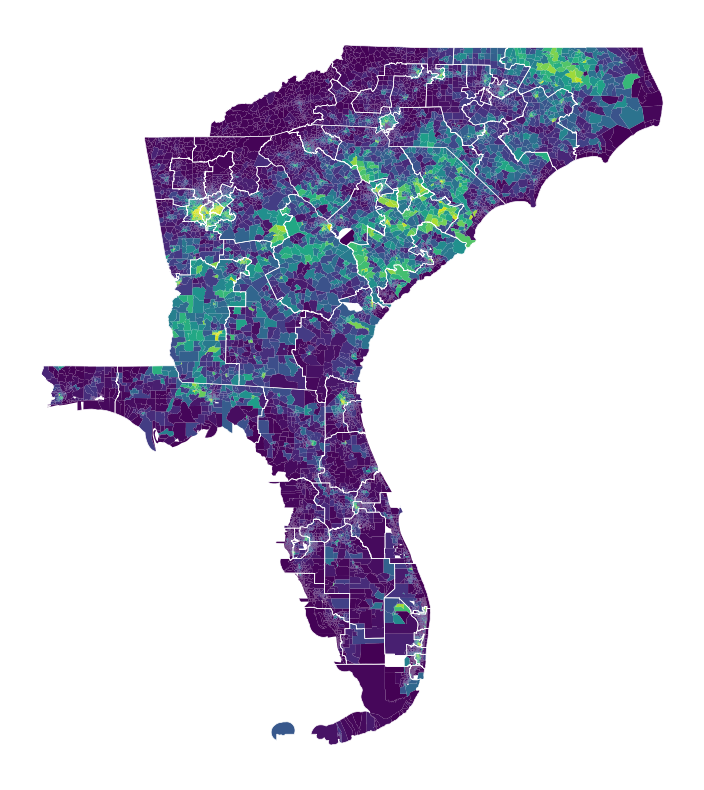

In [19]:
fig, ax = plt.subplots(figsize=(14,10))
df_nc['b_perc'] = df_nc['NH_Black']/df_nc['population']
df_sc['b_perc'] = df_sc['NH_Black']/df_sc['population']
df_ga['b_perc'] = df_ga['NH_Black']/df_ga['population']
df_fl['b_perc'] = df_fl['NH_Black']/df_fl['population']

df_nc.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
CON_NC.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='white',linewidth=0.5)
df_sc.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
CON_SC.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='white',linewidth=0.5)
df_ga.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
CON_GA.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='white',linewidth=0.5)
df_fl.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
CON_FL.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='white',linewidth=0.5)
ax.set_axis_off()

In [81]:
import matplotlib.colors as mcolors

# Define your explicit color transition
# This goes from Red -> Purple -> Blue
colors = ["red", "purple", "blue"]
custom_rgb_cmap = mcolors.LinearSegmentedColormap.from_list("RedPurpleBlue", colors)

In [150]:
dvote_share = sum(df_nc['G24PREDHAR']) + sum(df_sc['G24PREDHAR']) + sum(df_ga['G20PREDBID']) + sum(df_fl['G24PREDHAR'])
rvote_share = sum(df_nc['G24PRERTRU']) + sum(df_sc['G24PRERTRU']) + sum(df_ga['G20PRERTRU']) + sum(df_fl['G24PRERTRU'])

# of districts total in states
# of dem districts
dist_curr = len(set(df_nc['CON'])) + len(set(df_sc['CON'])) + len(set(df_fl['CON26'])) + len(set(df_ga['CON']))
dist_22 = len(set(df_nc['CON22'])) + len(set(df_sc['CON'])) + len(set(df_fl['CON22'])) + len(set(df_ga['CON']))

df_nc["prec_perc"] = df_nc['CON'].map(df_nc.groupby('CON')['G24PREDHAR'].sum()/(df_nc.groupby('CON')['G24PREDHAR'].sum() + df_nc.groupby('CON')['G24PRERTRU'].sum())) 
df_nc["prec_perc22"] = df_nc['CON22'].map(df_nc.groupby('CON22')['G24PREDHAR'].sum()/(df_nc.groupby('CON22')['G24PREDHAR'].sum() + df_nc.groupby('CON22')['G24PRERTRU'].sum())) 
df_sc["prec_perc"] = df_sc['CON'].map(df_sc.groupby('CON')['G24PREDHAR'].sum()/(df_sc.groupby('CON')['G24PREDHAR'].sum() + df_sc.groupby('CON')['G24PRERTRU'].sum())) 
df_ga["prec_perc"] = df_ga['CON'].map(df_ga.groupby('CON')['G20PREDBID'].sum()/(df_ga.groupby('CON')['G20PREDBID'].sum() + df_ga.groupby('CON')['G20PRERTRU'].sum())) 
df_fl["prec_perc"] = df_fl['CON26'].map(df_fl.groupby('CON26')['G24PREDHAR'].sum()/(df_fl.groupby('CON26')['G24PREDHAR'].sum() + df_fl.groupby('CON26')['G24PRERTRU'].sum())) 
df_fl["prec_perc22"] = df_fl['CON22'].map(df_fl.groupby('CON22')['G24PREDHAR'].sum()/(df_fl.groupby('CON22')['G24PREDHAR'].sum() + df_fl.groupby('CON22')['G24PRERTRU'].sum())) 

nc_dem = sum(df_nc.groupby('CON')['G24PREDHAR'].sum()/(df_nc.groupby('CON')['G24PREDHAR'].sum() + df_nc.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
nc_dem22 = sum(df_nc.groupby('CON22')['G24PREDHAR'].sum()/(df_nc.groupby('CON22')['G24PREDHAR'].sum() + df_nc.groupby('CON22')['G24PRERTRU'].sum()) > 0.5)
sc_dem = sum(df_sc.groupby('CON')['G24PREDHAR'].sum()/(df_sc.groupby('CON')['G24PREDHAR'].sum() + df_sc.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
ga_dem = sum(df_ga.groupby('CON')['G20PREDBID'].sum()/(df_ga.groupby('CON')['G20PREDBID'].sum() + df_ga.groupby('CON')['G20PRERTRU'].sum()) > 0.5)
fl_dem22 = sum(df_fl.groupby('CON22')['G24PREDHAR'].sum()/(df_fl.groupby('CON22')['G24PREDHAR'].sum() + df_fl.groupby('CON22')['G24PRERTRU'].sum()) > 0.5)
fl_dem = sum(df_fl.groupby('CON26')['G24PREDHAR'].sum()/(df_fl.groupby('CON26')['G24PREDHAR'].sum() + df_fl.groupby('CON26')['G24PRERTRU'].sum()) > 0.5)

In [151]:
print(dist_curr)
print(dist_22)
print(nc_dem + sc_dem + ga_dem + fl_dem)
print(nc_dem22 + sc_dem + ga_dem + fl_dem22)

print(dvote_share/(dvote_share + rvote_share))

63
63
13
21
0.4569630995677287


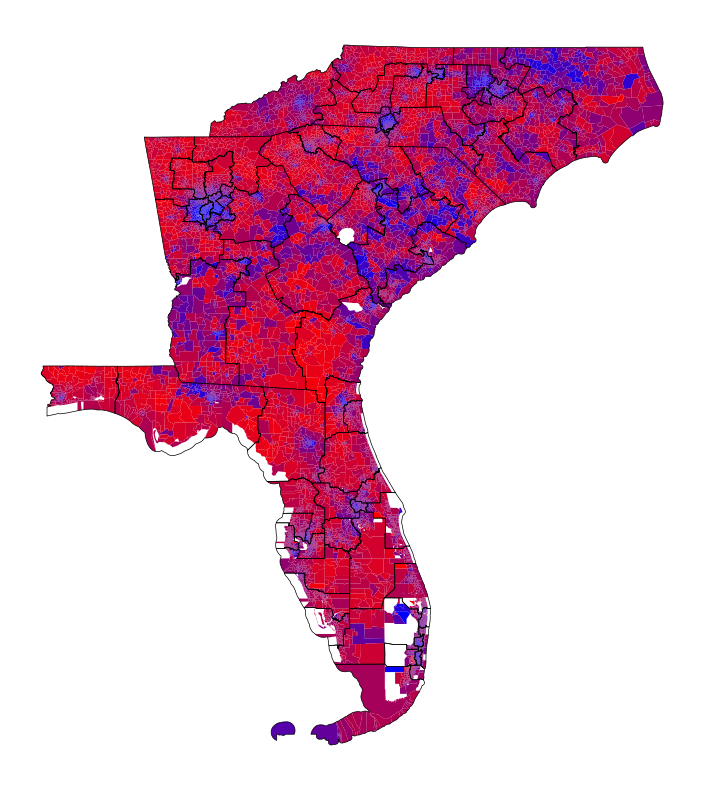

In [94]:
fig, ax = plt.subplots(figsize=(14,10))
df_nc["perc"] = df_nc['G24PREDHAR']/ (df_nc['G24PREDHAR'] + df_nc['G24PRERTRU'])
df_sc["perc"] = df_sc['G24PREDHAR']/ (df_sc['G24PREDHAR'] + df_sc['G24PRERTRU'])
df_ga["perc"] = df_ga['G20PREDBID']/ (df_ga['G20PREDBID'] + df_ga['G20PRERTRU'])
df_fl["perc"] = df_fl['G24PREDHAR']/ (df_fl['G24PREDHAR'] + df_fl['G24PRERTRU'])

df_nc.plot(column='perc',ax=ax,vmin=0, vmax=1, cmap=custom_rgb_cmap)
CON_NC.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='perc',ax=ax,vmin=0, vmax=1, cmap=custom_rgb_cmap)
CON_SC.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='perc',ax=ax,vmin=0, vmax=1, cmap=custom_rgb_cmap)
CON_GA.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='perc',ax=ax,vmin=0, vmax=1, cmap=custom_rgb_cmap)
CON_FL.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='k',linewidth=0.5)
ax.set_axis_off()

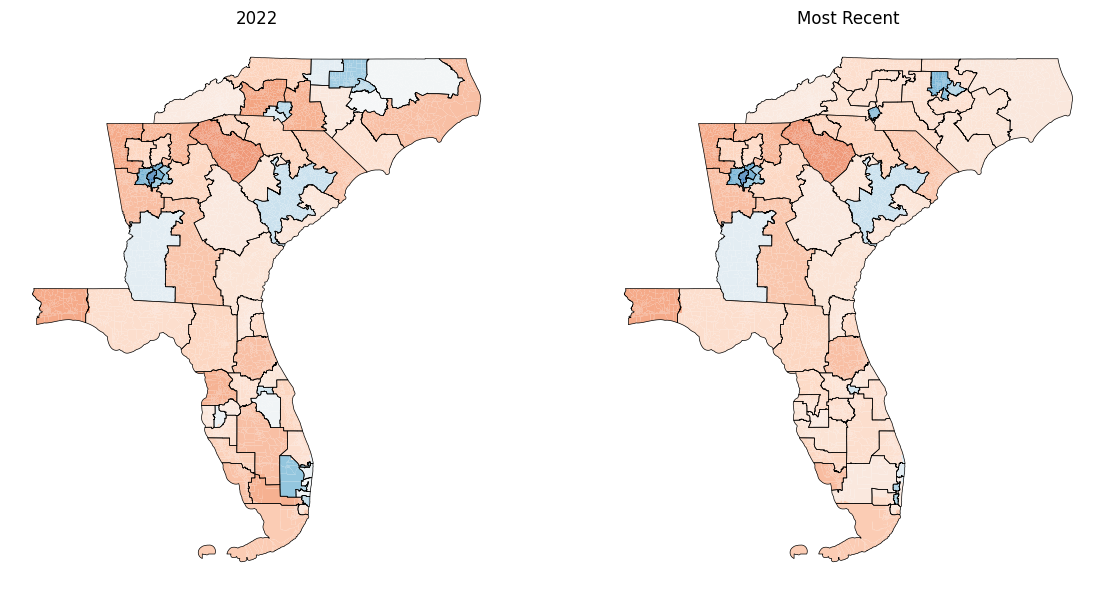

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14,10))

df_nc.plot(column='prec_perc22',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_NC22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_perc',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_perc',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_perc22',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_FL22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
ax[0].set_title("2022")
ax[0].set_axis_off()

df_nc.plot(column='prec_perc',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_NC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_perc',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_perc',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_perc',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_FL.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
ax[1].set_title("Most Recent")
ax[1].set_axis_off()

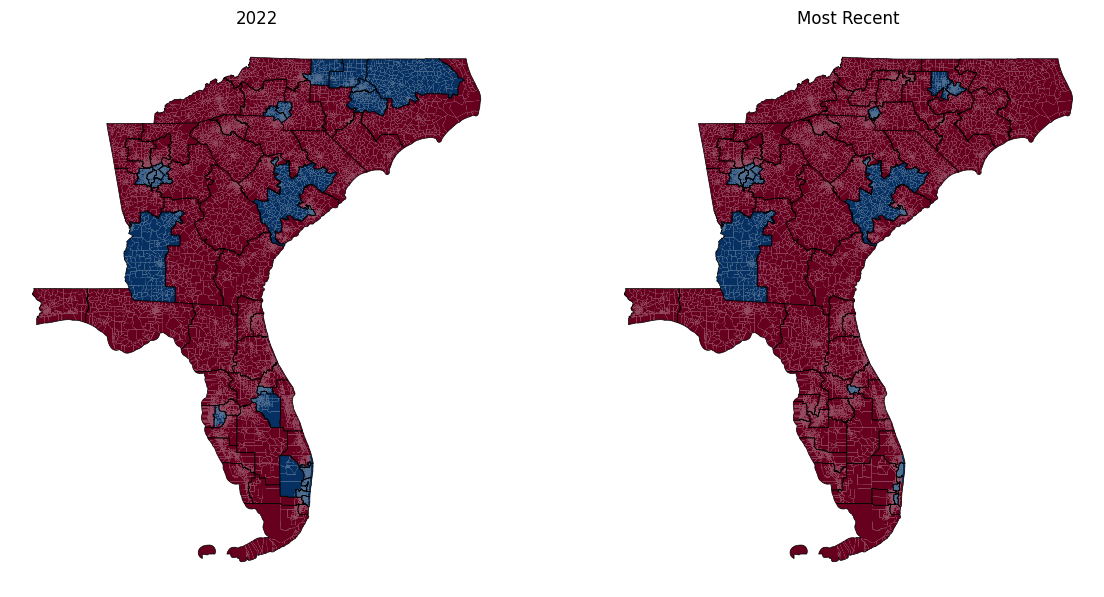

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14,10))

df_nc.plot(column='prec_perc22',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_NC22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_perc',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_perc',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_perc22',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_FL22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
ax[0].set_title("2022")
ax[0].set_axis_off()

df_nc.plot(column='prec_perc',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_NC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_perc',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_perc',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_perc',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_FL.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
ax[1].set_title("Most Recent")
ax[1].set_axis_off()

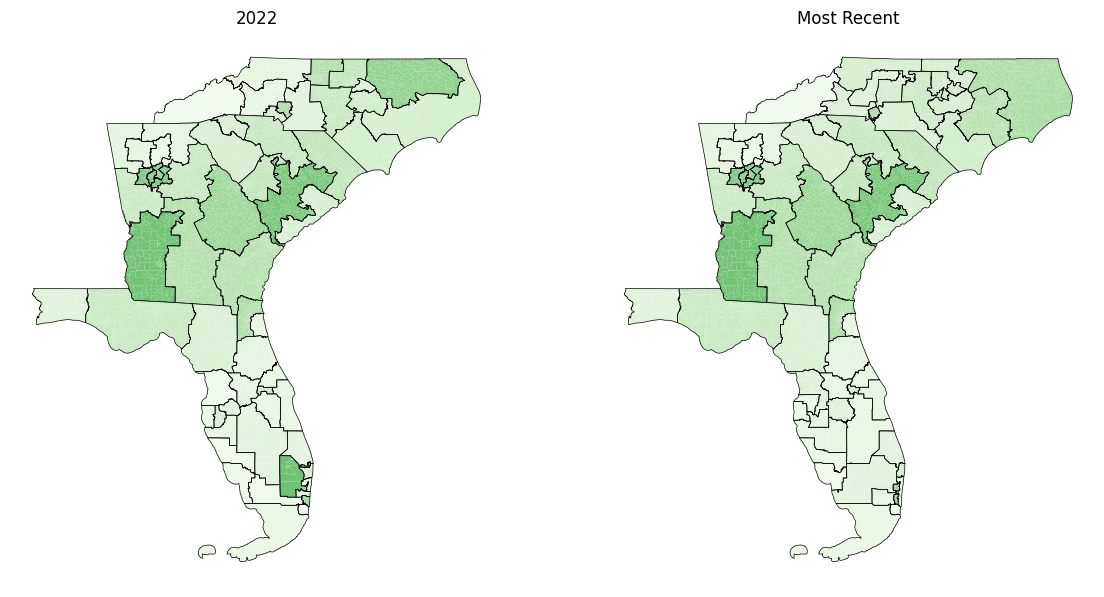

In [153]:
fig, ax = plt.subplots(1, 2, figsize=(14,10))

df_nc["prec_bperc"] = df_nc['CON'].map(df_nc.groupby('CON')['NH_Black'].sum()/df_nc.groupby('CON')['population'].sum())
df_nc["prec_bperc22"] = df_nc['CON22'].map(df_nc.groupby('CON22')['NH_Black'].sum()/df_nc.groupby('CON22')['population'].sum())
df_sc["prec_bperc"] = df_sc['CON'].map(df_sc.groupby('CON')['NH_Black'].sum()/df_sc.groupby('CON')['population'].sum()) 
df_ga["prec_bperc"] = df_ga['CON'].map(df_ga.groupby('CON')['NH_Black'].sum()/df_ga.groupby('CON')['population'].sum())
df_fl["prec_bperc"] = df_fl['CON26'].map(df_fl.groupby('CON26')['NH_Black'].sum()/(df_fl.groupby('CON26')['population'].sum()))
df_fl["prec_bperc22"] = df_fl['CON22'].map(df_fl.groupby('CON22')['NH_Black'].sum()/(df_fl.groupby('CON22')['population'].sum()))

df_nc.plot(column='prec_bperc22',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_NC22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_bperc',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_bperc',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_bperc22',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_FL22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
ax[0].set_title("2022")
ax[0].set_axis_off()

df_nc.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_NC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_FL.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
ax[1].set_title("Most Recent")
ax[1].set_axis_off()

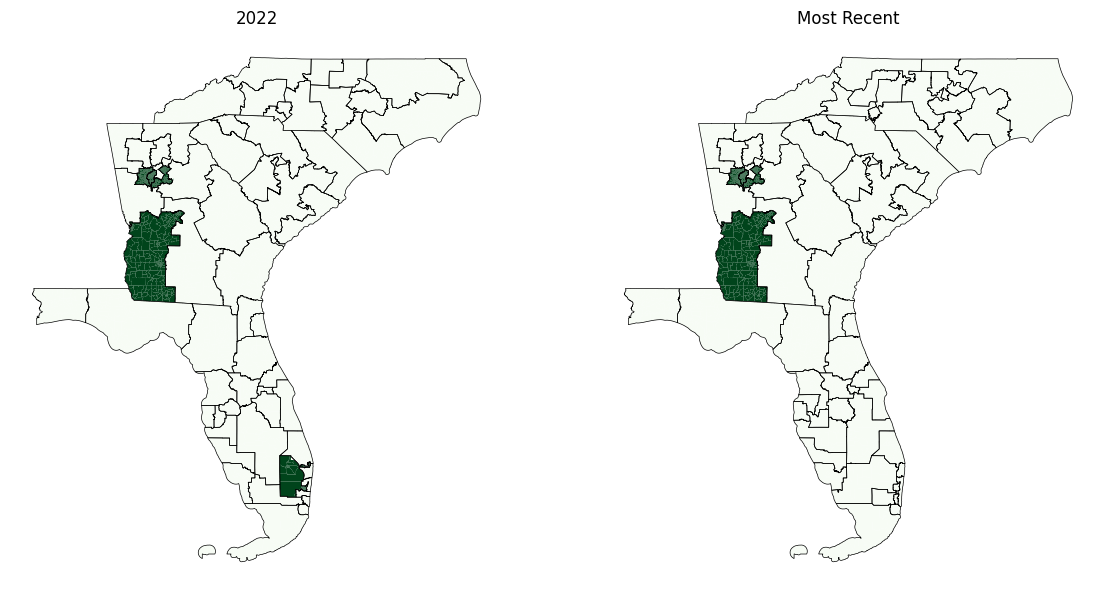

In [154]:
fig, ax = plt.subplots(1, 2, figsize=(14,10))

df_nc["prec_bperc"] = df_nc['CON'].map(df_nc.groupby('CON')['NH_Black'].sum()/df_nc.groupby('CON')['population'].sum()) > 0.5
df_nc["prec_bperc22"] = df_nc['CON22'].map(df_nc.groupby('CON22')['NH_Black'].sum()/df_nc.groupby('CON22')['population'].sum()) > 0.5
df_sc["prec_bperc"] = df_sc['CON'].map(df_sc.groupby('CON')['NH_Black'].sum()/df_sc.groupby('CON')['population'].sum()) > 0.5
df_ga["prec_bperc"] = df_ga['CON'].map(df_ga.groupby('CON')['NH_Black'].sum()/df_ga.groupby('CON')['population'].sum()) > 0.5
df_fl["prec_bperc"] = df_fl['CON26'].map(df_fl.groupby('CON26')['NH_Black'].sum()/(df_fl.groupby('CON26')['population'].sum())) > 0.5
df_fl["prec_bperc22"] = df_fl['CON22'].map(df_fl.groupby('CON22')['NH_Black'].sum()/(df_fl.groupby('CON22')['population'].sum())) > 0.5

df_nc.plot(column='prec_bperc22',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_NC22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_bperc',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_bperc',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_bperc22',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_FL22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
ax[0].set_title("2022")
ax[0].set_axis_off()

df_nc.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_NC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_FL.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
ax[1].set_title("Most Recent")
ax[1].set_axis_off()

In [ ]:
fig, ax = plt.subplots(figsize=(14,10))
df['b_perc'] = df['NH_Black']/df['population']
df.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
CON.to_crs(df.crs).plot(ax=ax, facecolor='None',edgecolor='white',linewidth=0.5)
ax.set_axis_off()

In [35]:
max(df['d_perc'])

2.9466019417475726

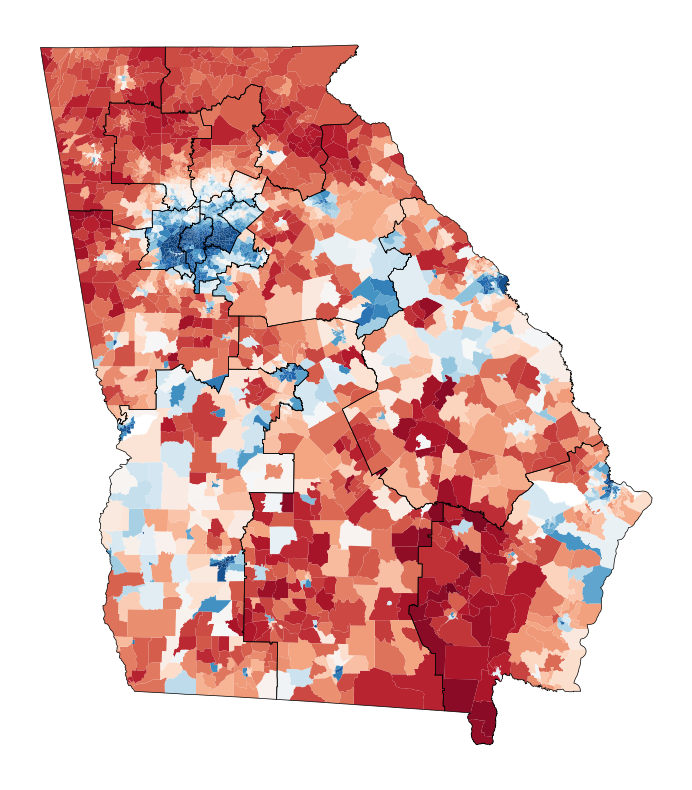

In [43]:
fig, ax = plt.subplots(figsize=(14,10))
df['d_perc'] = df['G20PREDBID']/ (df['G20PREDBID'] + df['G20PRERTRU'])
df.plot(column='d_perc',ax=ax,vmin=0, vmax=1, cmap='RdBu')
CON.to_crs(df.crs).plot(ax=ax, facecolor='None',edgecolor='black',linewidth=0.5)
ax.set_axis_off()

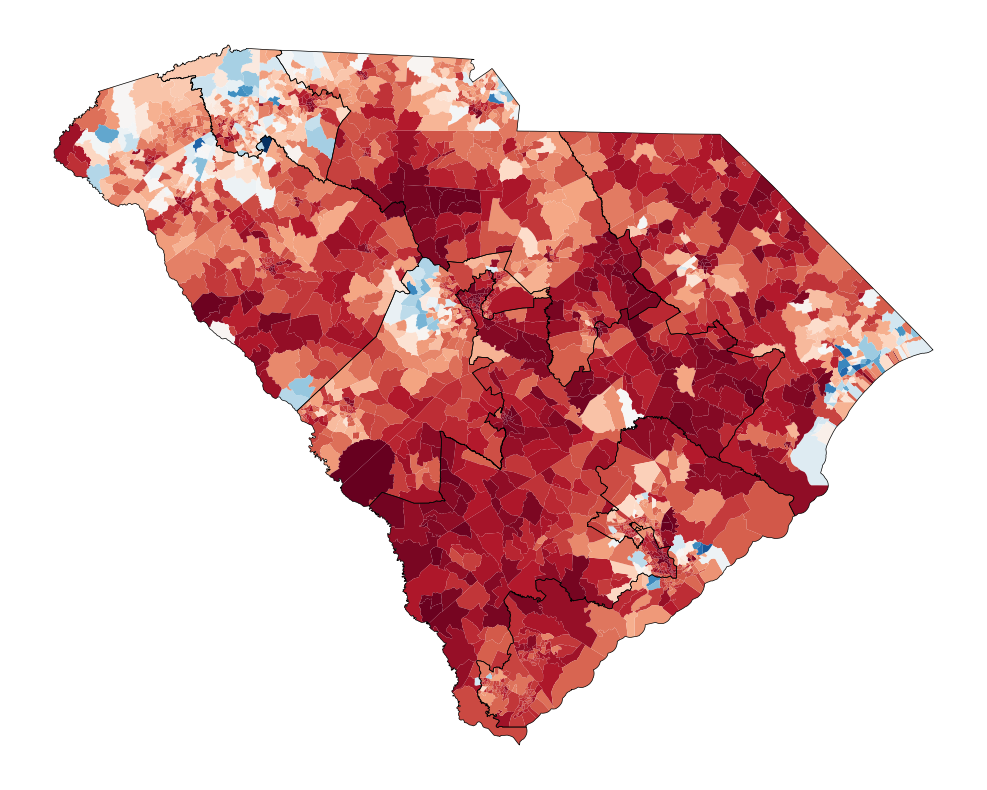

In [ ]:
fig, ax = plt.subplots(figsize=(14,10))
df.plot(column='G24PRERTRU', ax=ax,cmap='RdBu')
CON.to_crs(df.crs).plot(ax=ax, facecolor='None',edgecolor='black',linewidth=0.5)
ax.set_axis_off()

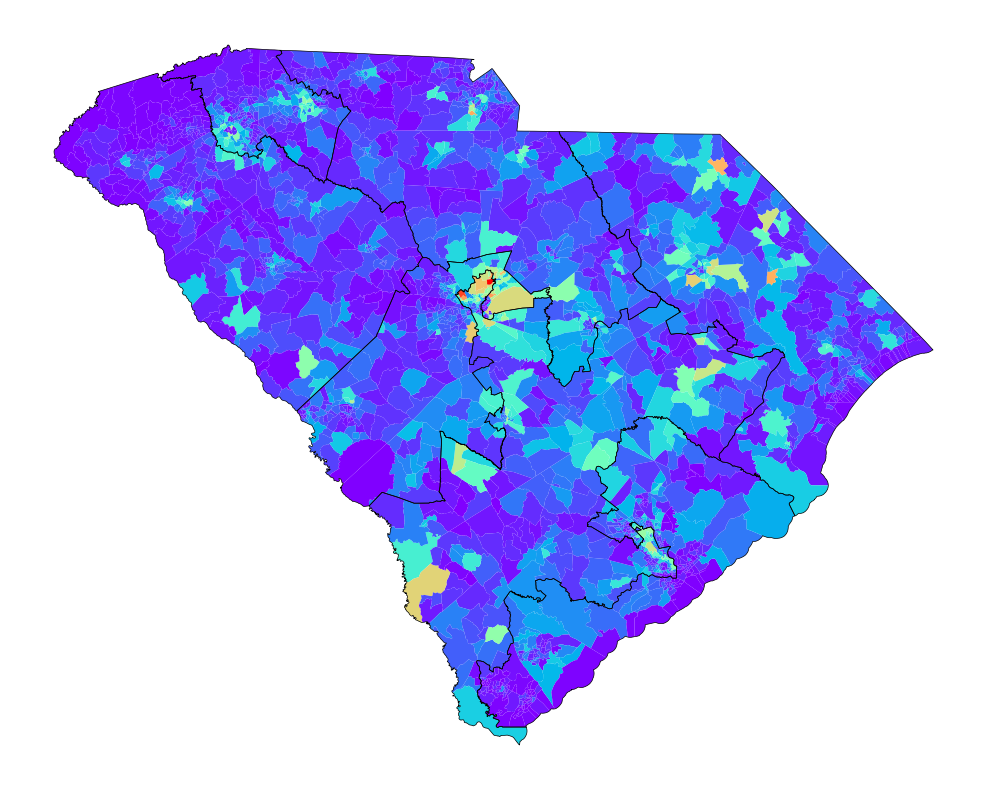

In [6]:
fig, ax = plt.subplots(figsize=(14,10))
df.plot(column='NH_Black', ax=ax,cmap='rainbow')
CON.to_crs(df.crs).plot(ax=ax, facecolor='None',edgecolor='black',linewidth=0.5)
ax.set_axis_off()